In [1]:
using Statistics
using CairoMakie
using CairoMakie.Colors
using Oceananigans
using Interpolations
include("src-fig/plotting.jl")
include("src-fig/figures/regions.jl")

foldername = "../scratch/turbulence-at-fronts/Strain"

DFM = joinpath(foldername, "DFM.jld2")
iterations, times = iterations_times(DFM)
sp = simulation_parameters(DFM)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
inds = center_indices(DFM)
frames = [21, 201, 561];

[ Info: Oceananigans will use 4 threads


## Pre-initial conditions

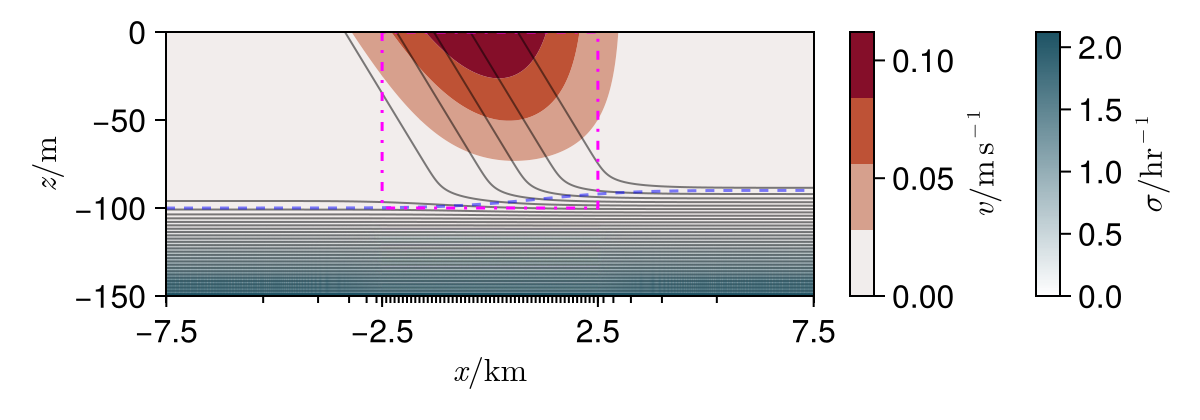

In [2]:
include("src-fig/figures/preinitial_conditions.jl")
include("src-simulation/parameters.jl")

fig = preinitial_conditions(sp)

save("figures/paper/preinitial.png", fig; px_per_unit=4)
#save("figures/paper/preinitial.png", fig)

fig

## Movies

In [ ]:
include("src-fig/video/full_video.jl")

full_video(foldername, "full.mp4", 21:820, -50;
    background = true, 
    fig_kw = (; fontsize=18), 
    record_kw = (; px_per_unit=2),
    ht_u_kw = (; highclip=nothing, lowclip=nothing),
    σq = (10, 1),
    ax_hist_kw = (; limits=(-1, 1, -1e3, 9e3), yticks=([0, 3000, 6000, 9000], ["", "", "", ""]), ylabel=L"\text{Counts} / \text{Ri}")
)

29 / 800 

## Hovmoller

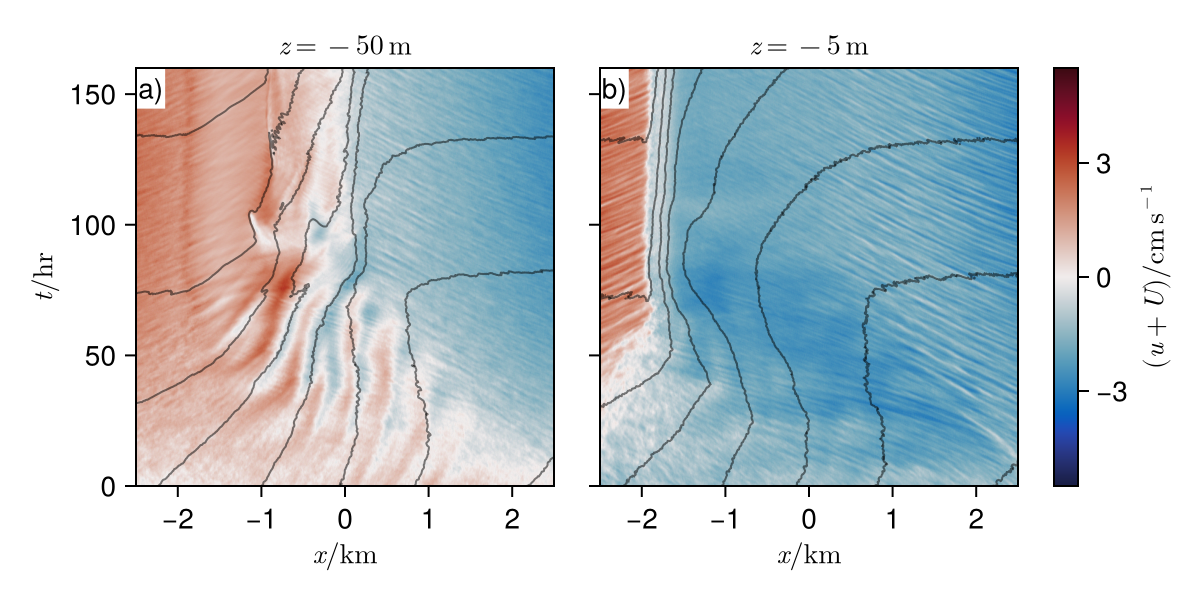

In [6]:
include("src-fig/figures/hovmoller.jl")

fig = hovmoller(foldername, -50; 
    fig_kw=(; size=(600, 300), fontsize=14), 
    ax_kw=(; limits=(-2.5, 2.5, 0, 160), yticks=[0, 50, 100, 150]), 
    ht_kw=(; colorrange=(-5.5, 5.5)), 
    σ=1, 
    background=true
)

save("figures/paper/hovmoller.png", fig; px_per_unit=4)
#save("figures/paper/hovmoller.svg", fig)

fig

## Across-front velocity

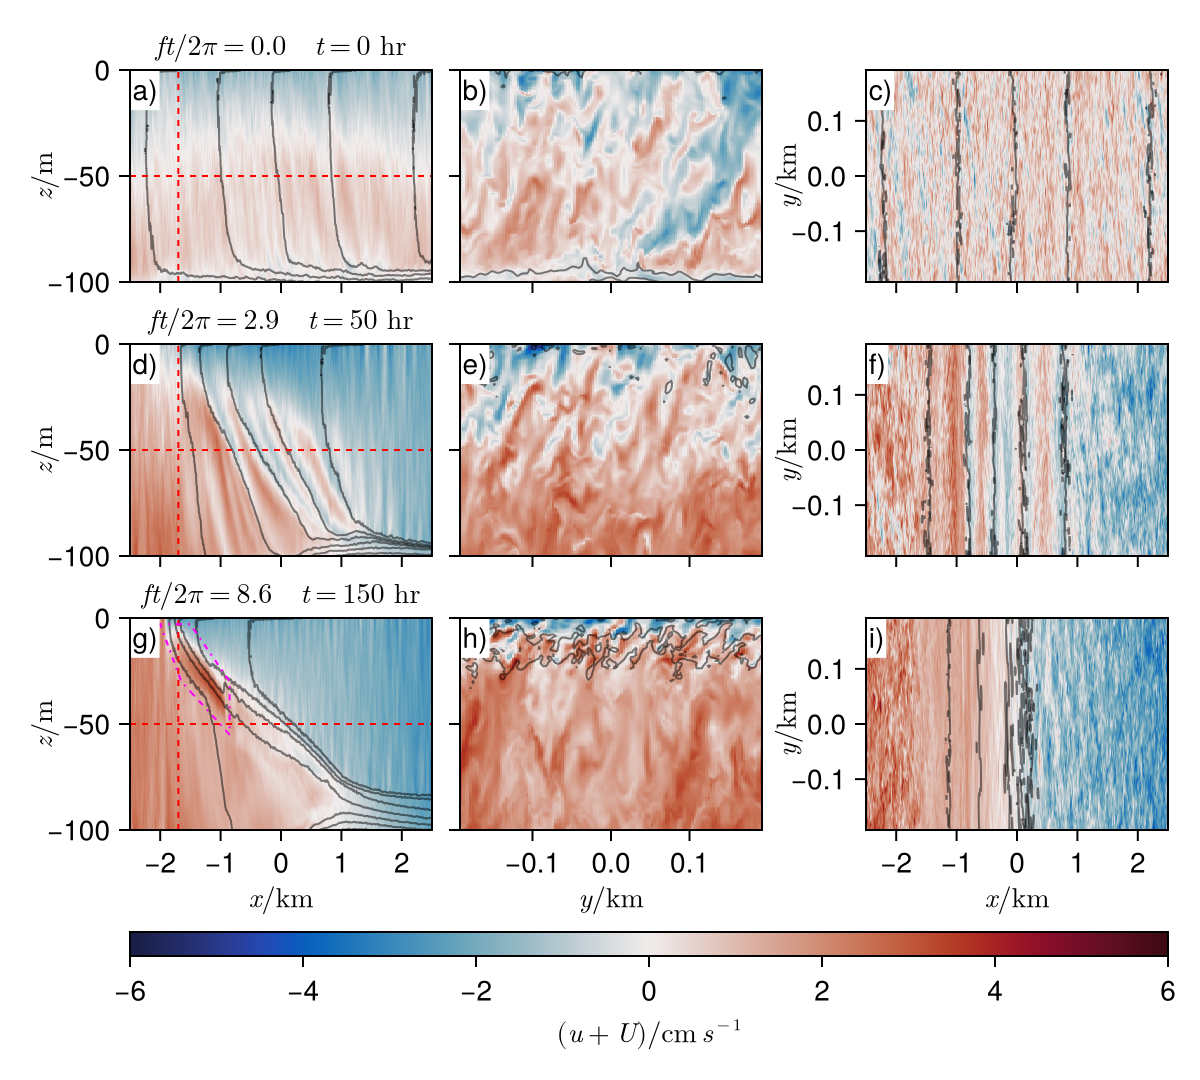

In [7]:
include("src-fig/figures/u_evolution.jl")
include("src-fig/figures/regions.jl")
#=
for frame in frames
    fig = u_evolution(foldername, [frame], frame == 561 ? regions.arrest : nothing; 
        fig_kw = (; fontsize=16, size=(600, 270)), 
        background = true, 
        ht_kw = (; colorrange=(-5, 5)),
        arrow = false
    )
    save("figures/paper/u-$(frame).png", fig; px_per_unit=2)
end
=#
fig = u_evolution(foldername, frames, -1700, regions.arrest; 
    fig_kw = (; fontsize=14, size=(600, 540)), 
    background = true, 
    ax_kw = (; ylabelpadding=-6.0),
    axh_kw = (; ylabelpadding=-6.0),
    ax_slice_kw = (; ylabelpadding=-6.0),
    ht_kw = (; colorrange=(-6, 6)),
    arrow = false,
)
rowgap!(fig.layout, Relative(0.02))
rowgap!(fig.layout, 3, Relative(0.03))
colgap!(fig.layout, Relative(0.02))
colgap!(fig.layout, 2, Relative(0.015))

save("figures/paper/u-evolution.png", fig; px_per_unit=4)
#save("figures/paper/u-evolution.svg", fig)

fig

## Turbulent kinetic energy

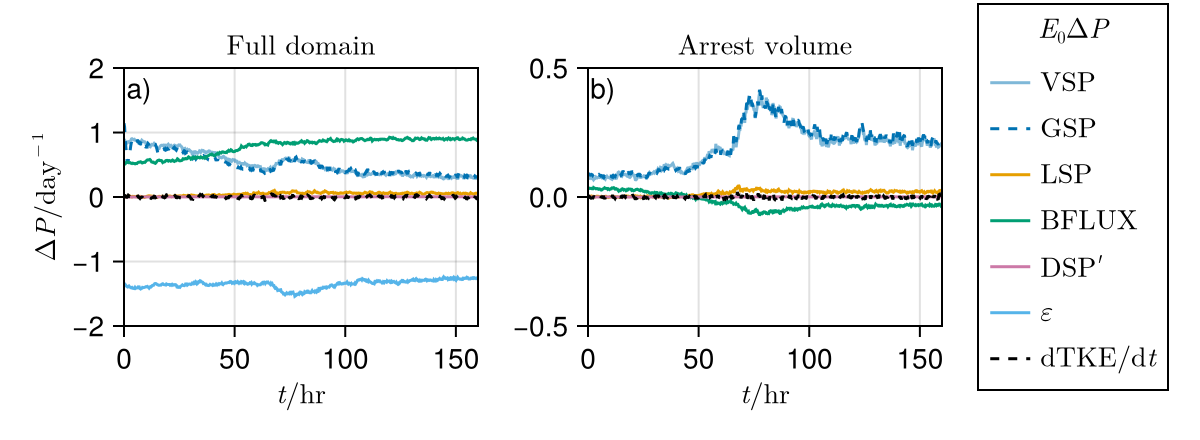

In [8]:
include("src-fig/figures/tke_by_region.jl")
include("src-fig/figures/regions.jl")

fig = tke_by_region(foldername, []; 
    fig_kw=(; size=(600, 220), fontsize=14),
    ax_kw=(; xticks=[0, 50, 100, 150])
)

save("figures/paper/tke.png", fig; px_per_unit=4)
#save("figures/paper/tke.svg", fig)

fig

## Potential vorticity

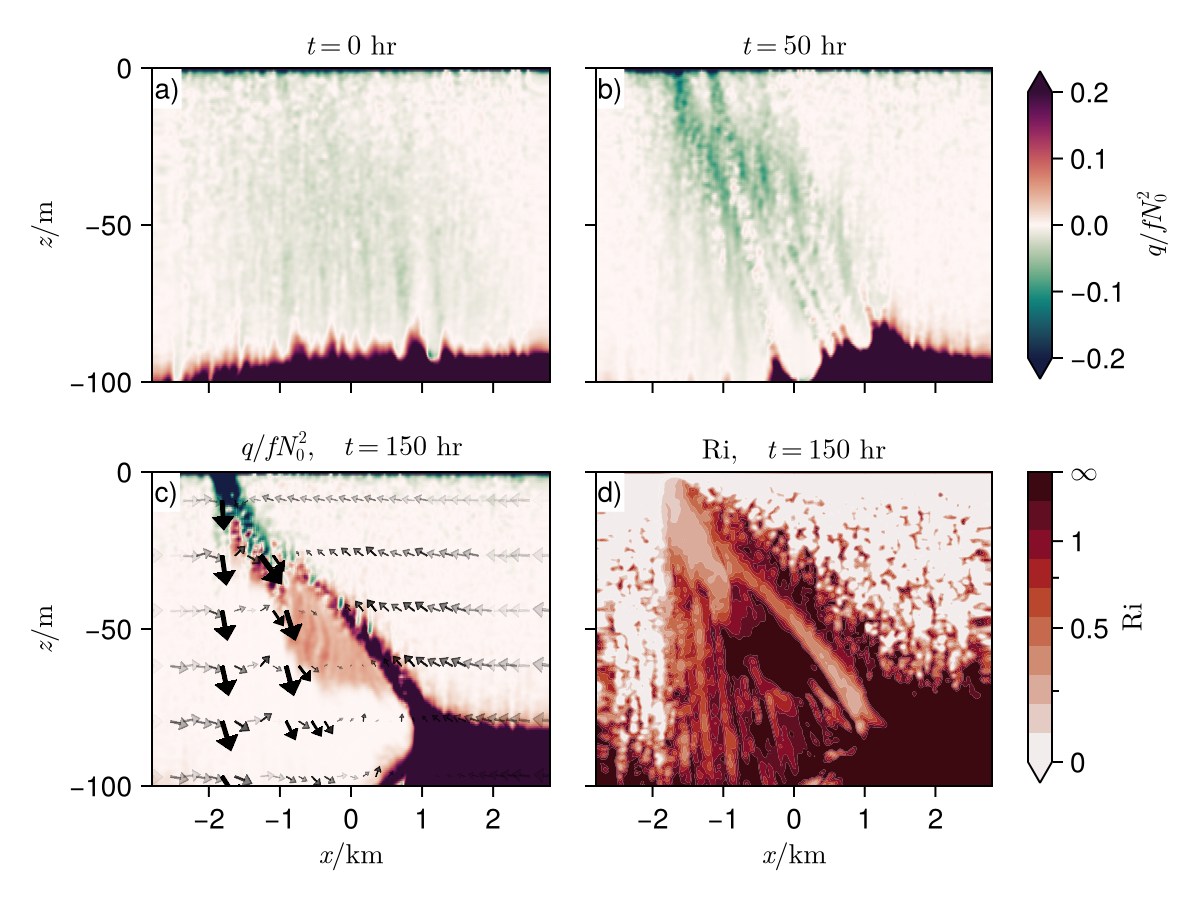

In [9]:
include("src-fig/figures/regions.jl")
include("src-fig/figures/pv_plot.jl")

fig_kw = (;
    size = (600, 450),
    fontsize = 14
)
ax_kw = (; 
    xticks = -2:2,
    limits = (-2.8, 2.8, -100, 0),
)
ht_kw = (; 
    colorrange = (-0.2, 0.2)
)
fig = pv_plot(foldername, 21, 201, 561; fig_kw, ax_kw, σ=(10, 0), ht_kw, arrow=true)

#save("figures/paper/pv.svg", fig)
save("figures/paper/pv.png", fig; px_per_unit=4)

fig